# Emulation of Waves
## Weather Typing + Probabilistic - Copula Model
## Predictor- Load Weather Types

In [ ]:
from bluemath_tk.core.io import load_model

daily_xwt = load_model("outputs/dwt_model_oporto.pkl")
dwts_to_fit = (
    daily_xwt.steps.get("pca")
    .pcs.kma_bmus.to_dataset(name="bmus")
    .sel(time=slice("1979", "2018"))
)
dwts_to_fit["cenEOFs"] = (
    ("n_clusters", "n_features"),
    daily_xwt.steps.get("kma").kma.cluster_centers_,
)
dwts_to_fit

<xarray.Dataset> Size: 179kB
Dimensions:  (time: 14610, n_clusters: 36, n_features: 23)
Coordinates:
  * time     (time) datetime64[s] 117kB 1979-01-01 1979-01-02 ... 2018-12-31
Dimensions without coordinates: n_clusters, n_features
Data variables:
    bmus     (time) int32 58kB 12 12 14 27 29 34 30 28 ... 23 27 28 35 34 34 26
    cenEOFs  (n_clusters, n_features) float32 3kB -23.1 -2.493 ... 1.092 0.9429

## Predictand- Load regional/local wave data
### significant wave height, peak period, mean wave direction

In [ ]:
import xarray as xr

predictand = (
    xr.open_dataset("inputs/daily_predictand_1979_2018_Oporto.nc")
    .sel(time=dwts_to_fit.time, method="nearest", tolerance="1H")
    .rename({"swh": "bulk_Hs", "pp1d": "bulk_Tp", "mwd": "bulk_Dir"})
)
predictand["EF"] = predictand.bulk_Hs**2 + predictand.bulk_Tp
predictand["bmus"] = (("time"), dwts_to_fit["bmus"].values)
predictand

<xarray.Dataset> Size: 760kB
Dimensions:   (time: 14610)
Coordinates:
  * time      (time) datetime64[ns] 117kB 1979-01-01 1979-01-02 ... 2018-12-31
Data variables:
    bulk_Hs   (time) float64 117kB 0.9979 1.402 2.481 ... 1.188 0.9691 0.9028
    bulk_Tp   (time) float64 117kB ...
    bulk_Dir  (time) float64 117kB ...
    ss        (time) float64 117kB ...
    EF        (time) float64 117kB 6.84 8.322 14.03 29.84 ... 8.365 6.75 6.592
    bmus      (time) int32 58kB 12 12 14 27 29 34 30 28 ... 23 27 28 35 34 34 26

## Predictand to Predictor- Model
## Probabilistic - Copula Model

In [18]:
from bluemath_tk.teslakit.climate_emulator import Climate_Emulator

ce = Climate_Emulator("outputs/emulator")

config = {
    "waves_families": ["bulk"],
    "distribution": [("ss", "Empirical")],
    "do_chromosomes": False,
    "extra_variables": ["ss"],
}
ce.FitExtremes(KMA=dwts_to_fit, WVS=predictand, config=config, proxy="EF")

Waves Families: ['bulk']
Extra Variables: ['ss']
GEV distribution: ['bulk_Hs', 'bulk_Tp']
Empirical distribution: ['bulk_Dir', 'ss']
Weibull distribution: []
Do chromosomes combinations: False
Max. Storms PROXY: EF


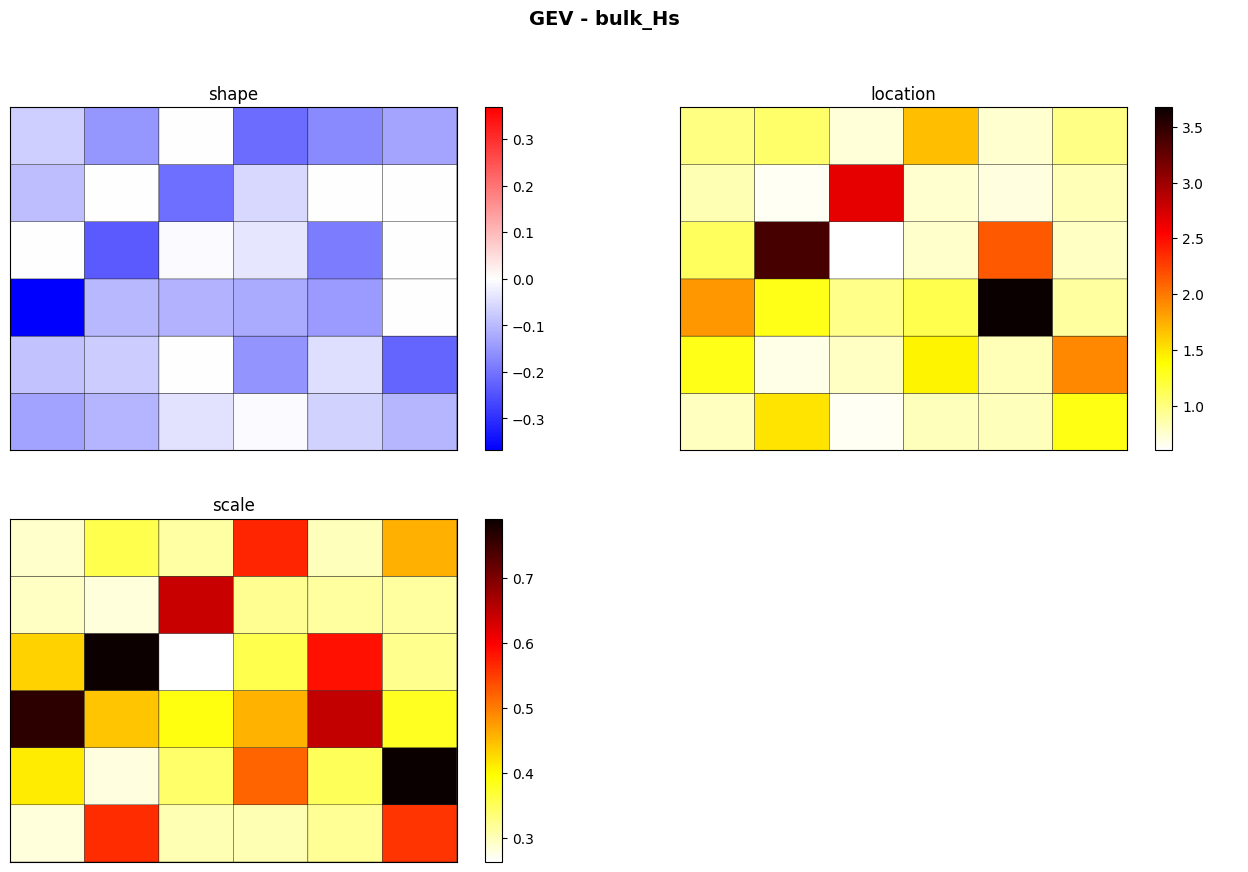

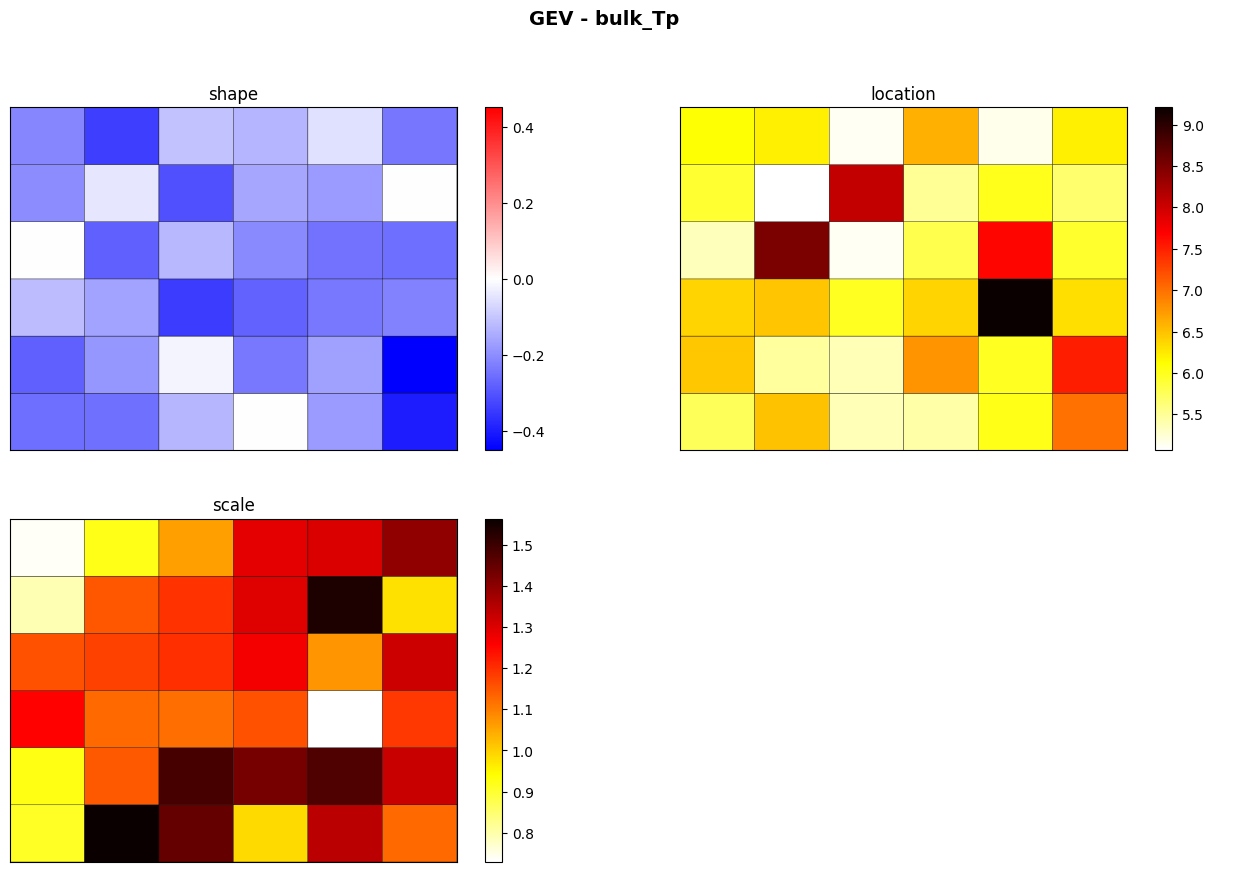

In [20]:
# Fit report figures

ce.Report_Fit(vns_GEV=["Hs", "Tp"], plot_chrom=False, plot_sigma=False);

## Climate Emulator
### Emulation of Weather Types + Emulation of Waves

In [21]:
# Load simulated DWTs

simulated_dwts = xr.open_dataset("outputs/xds_output.nc")
simulated_dwts

<xarray.Dataset> Size: 2MB
Dimensions:      (time: 36891, n_sim: 5)
Coordinates:
  * time         (time) datetime64[ns] 295kB 1999-01-01 ... 2100-01-01
Dimensions without coordinates: n_sim
Data variables:
    evbmus_sims  (time, n_sim) int64 1MB ...
    ofbmus_sims  (time, n_sim) bool 184kB ...

In [22]:
simulated_waves = ce.Simulate_Waves(simulated_dwts.isel(n_sim=0), 1)
simulated_waves

C.E: Sim. Waves: 100%|██████████| 22649/22649 [03:25<00:00, 110.17it/s]


<xarray.Dataset> Size: 1MB
Dimensions:   (n_sim: 1, time: 22649)
Coordinates:
  * time      (time) datetime64[ns] 181kB 1999-01-01 1999-01-02 ... 2100-01-01
Dimensions without coordinates: n_sim
Data variables:
    DWT       (n_sim, time) int64 181kB 12 14 27 23 29 12 ... 32 34 29 33 26 26
    bulk_Hs   (n_sim, time) float64 181kB 1.401 2.749 1.979 ... 0.9665 1.47
    bulk_Tp   (n_sim, time) float64 181kB 8.014 8.192 7.473 ... 5.341 9.348
    bulk_Dir  (n_sim, time) float64 181kB 303.2 175.6 311.3 ... 4.93 279.5 243.8
    ss        (n_sim, time) float64 181kB 0.05067 0.05033 ... 0.013 0.06462

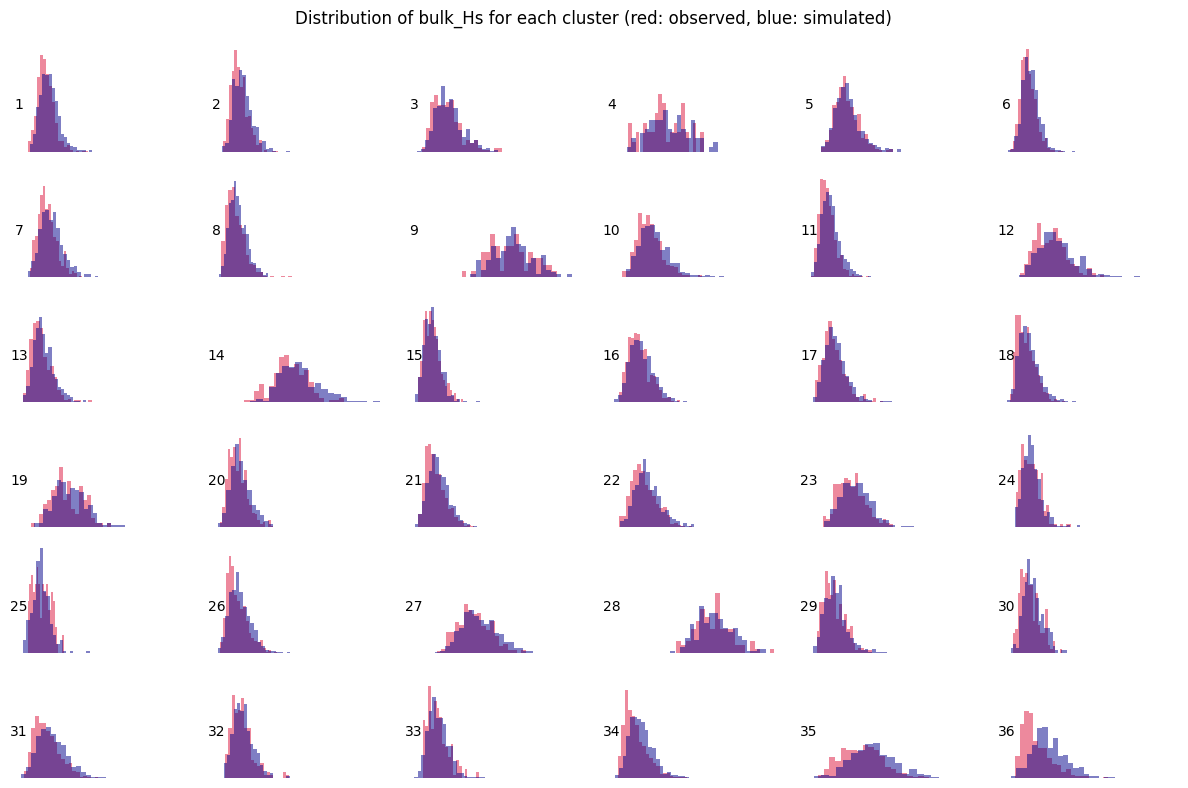

In [25]:
import matplotlib.pyplot as plt

var_to_plot = "bulk_Hs"

fig, axes = plt.subplots(6, 6, figsize=(12, 8), sharex=True, sharey=True)
for cluster, ax in enumerate(axes.flatten()):
    predictand.isel(time=predictand.groupby("bmus").groups.get(cluster + 1))[
        var_to_plot
    ].plot.hist(ax=ax, density=True, alpha=0.5, bins=20, color="crimson")
    simulated_waves.isel(time=simulated_waves.groupby("DWT").groups.get(cluster + 1))[
        var_to_plot
    ].plot.hist(ax=ax, density=True, alpha=0.5, bins=20, color="darkblue")
    ax.axis("off")
    ax.text(0, 0.7, f"{cluster + 1}", fontsize=10, ha="center", va="center")
    fig.suptitle(
        f"Distribution of {var_to_plot} for each cluster (red: observed, blue: simulated)",
        fontsize=12,
        ha="center",
        va="top",
    )
plt.subplots_adjust(top=0.9)
plt.tight_layout()

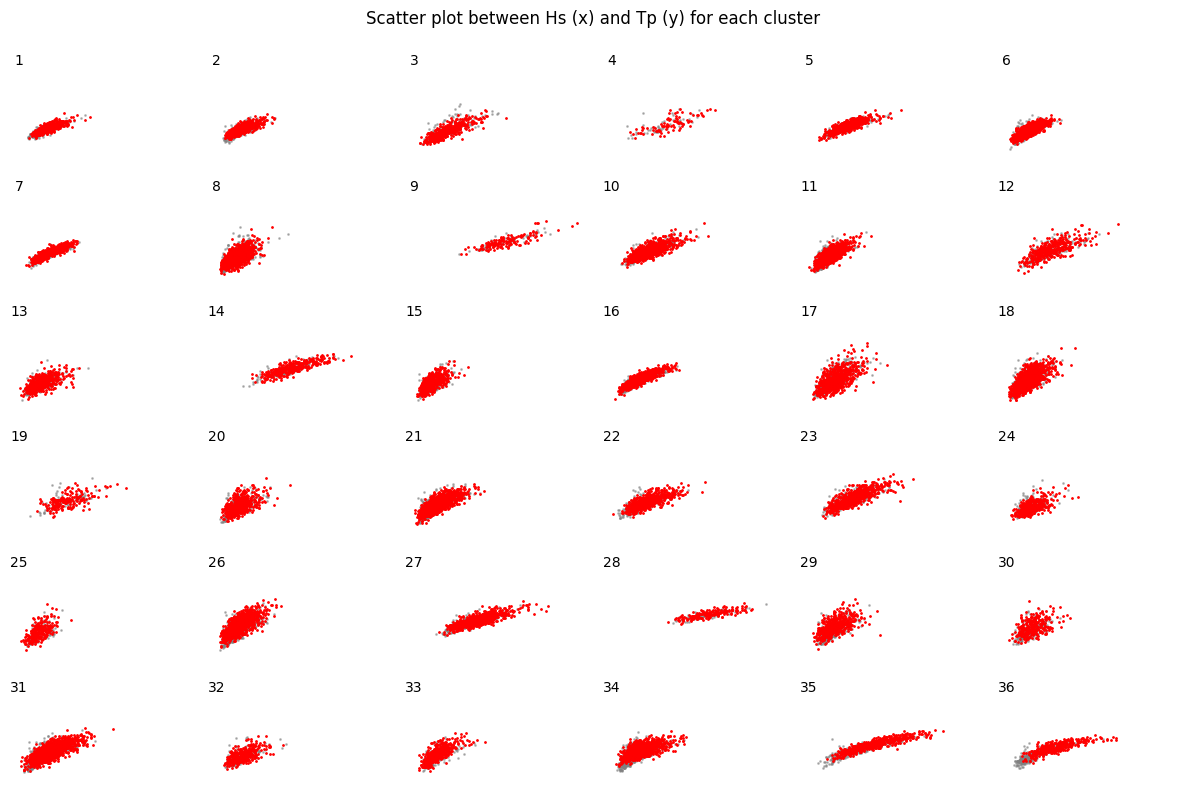

In [ ]:
import matplotlib.colors as mcolors
import numpy as np

cmap = plt.cm.get_cmap("bwr")
norm = mcolors.Normalize(vmin=-0.5, vmax=0.5)
# Get correlation values
corr_values = np.array([ce.sigma[cluster][0]["corr"][0, 1] for cluster in range(1, 37)])
# Get colors for the correlation values
corr_values_colors = [cmap(norm(value)) for value in corr_values]
# Plot the correlation values
fig, axes = plt.subplots(6, 6, figsize=(12, 8), sharex=True, sharey=True)
for cluster, ax in enumerate(axes.flatten()):
    predictand.isel(
        time=predictand.groupby("bmus").groups.get(cluster + 1)
    ).plot.scatter(ax=ax, x="bulk_Hs", y="bulk_Tp", s=1, color="grey", alpha=0.5)
    simulated_waves.isel(
        time=simulated_waves.groupby("DWT").groups.get(cluster + 1)
    ).plot.scatter(
        ax=ax, x="bulk_Hs", y="bulk_Tp", s=1, color=corr_values_colors[cluster]
    )
    ax.axis("off")
    ax.text(0, 20, f"{cluster + 1}", fontsize=10, ha="center", va="center")
fig.suptitle(
    "Scatter plot between Hs (x) and Tp (y) for each cluster",
    fontsize=12,
    ha="center",
    va="top",
)
plt.subplots_adjust(top=0.9)
plt.tight_layout()